# Organic single-product model vs. conventional multi-product model
This notebook combines the multi-product model of `applied_multi_product.ipynb` with the
possibility of **organic farming** in the single-product model (as in `organic_implementation.py`).
Data: the Indian farmer survey
[Link to survey](https://www-sciencedirect-com.vu-nl.idm.oclc.org/science/article/pii/S2352340922008319)

## Structure
1. **Data preparation**: identical to `applied_multi_product.ipynb` (P and Q pairs for Improved, Hybrid and Local).
2. **Models**: the multi-product LSV (numerical) and Variance (analytical, active-set) models are reused unchanged;
   a target shortfall variance (TSV) model is added. The organic option is a *single-product* model on the Local crop with a yield loss
   $Q_{org} = Z \cdot Q_{local}$, $Z \sim N(0.94,\ 0.0702^2)$.
3. **Combined Pareto front**: the organic single-product front against the conventional multi-product front
   under Variance, LSV and TSV. All crops (conventional and organic) use credibility level $a = 0.8$,
   as in `examine_forward_price_influence` of `organic_implementation.py`.
4. **Forward price influence**: how the organic forward price $f_{org} = pm \cdot \mathbb{E}[P_{org}]$ changes
   whether the organic single-product option is preferred over the multi-product portfolio.

In [2]:
# Run once. Comment out if cvxpy is already installed in your environment.
# %pip install cvxpy numpy pandas matplotlib tqdm -q

In [3]:
import numpy as np
import pandas as pd
import cvxpy as cp
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from tqdm.auto import tqdm

np.random.seed(0)

C:\Users\lbr476\AppData\Roaming\uv\python\cpython-3.14-windows-x86_64-none\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
farmer_data = pd.read_csv('crop_yield.csv', low_memory=False)

#### Filter data ####

farmer_data['time'] = pd.to_datetime(farmer_data['L-q601_harvestDate'], errors='coerce', dayfirst=True)

# Filter out rows with invalid or missing time values
farmer_data = farmer_data.dropna(subset=['time'])

farmer_data = farmer_data[(farmer_data['M-q706_cropSP'] < 10000) & (farmer_data['M-q706_cropSP'] > 0)].copy()  # Remove outliers
farmer_data = farmer_data[farmer_data['C-q306_cropLarestAreaAcre'] > 0]

farmer_data['time'] = pd.to_datetime(farmer_data['L-q601_harvestDate'], errors='coerce', dayfirst=True)

# Filter out rows with invalid or missing time values
farmer_data = farmer_data.dropna(subset=['time'])

C:\Users\lbr476\AppData\Local\Temp\ipykernel_23404\3181400201.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  farmer_data['time'] = pd.to_datetime(farmer_data['L-q601_harvestDate'], errors='coerce', dayfirst=True)


In [5]:
# Convert yield per hectare to quintale per hectare
farmer_data['hectare_yield'] = farmer_data['L-tonPerHectare']
rupee_to_euro = 0.0091 # Exchange rate # 04-08-2026
farmer_data['euro_spot_price'] = farmer_data['M-q706_cropSP'] * rupee_to_euro * 10 # Convert to ton and then to euros

farmer_data["crop"] = farmer_data["D-q409_varType"]

crop_names = ["Improved", "Hybrid", "Local"]

full_data = []

# Helper: get neighbors by hierarchical location
def get_neighbors_with_time(source_row, target_df, k=3):
    levels = [
        "A-q105_village",
        "A-q104_subDistrict",
        "A-q103_district",
        "A-q102_state",
    ]

    for level in levels:
        matches = target_df[
            (target_df[level] == source_row[level]) &
            (target_df["time"].dt.to_period("M") ==
             source_row["time"].to_period("M"))
        ]
        if not matches.empty:
            return matches.nsmallest(k, "hectare_yield")  # Return closest k matches by yield

    # Fallback: closest in time
    target_df = target_df.copy()
    target_df["timediff"] = (target_df["time"] - source_row["time"]).abs()
    return target_df.nsmallest(k, "timediff")

total_rows = len(farmer_data)

for _, row in tqdm(
    farmer_data.iterrows(),
    total=total_rows,
    desc="Processing farmers",
    unit="farmer"
):

    crop = row["crop"]

    # Initialize dictionaries
    yield_vector = {c: np.nan for c in crop_names}
    price_vector = {c: np.nan for c in crop_names}

    # Observed crop
    yield_vector[crop] = row["hectare_yield"]
    price_vector[crop] = row["euro_spot_price"]

    # Estimate missing crops using neighbors
    for other_crop in [c for c in crop_names if c != crop]:

        target_df = farmer_data[farmer_data["crop"] == other_crop]
        nn = get_neighbors_with_time(row, target_df)

        if not nn.empty:
            yield_vector[other_crop] = nn["hectare_yield"].mean()
            price_vector[other_crop] = nn["euro_spot_price"].mean()

    # Store [Q_improved, Q_hybrid, Q_local, P_improved, P_hybrid, P_local]
    full_data.append(
        [yield_vector[c] for c in crop_names] +
        [price_vector[c] for c in crop_names]
    )


# Convert to array and remove incomplete rows
data_matrix = np.array(full_data, dtype=float)
data_matrix = data_matrix[~np.isnan(data_matrix).any(axis=1)]

print(f"Data matrix shape: {data_matrix.shape}")

Processing farmers:   0%|          | 0/7926 [00:00<?, ?farmer/s]

Processing farmers: 100%|██████████| 7926/7926 [08:04<00:00, 16.34farmer/s]

Data matrix shape: (7926, 6)


In [6]:
columns = [
    "Q_Improved",
    "Q_Hybrid",
    "Q_Local",
    "P_Improved",
    "P_Hybrid",
    "P_Local"
]

data_df = pd.DataFrame(data_matrix, columns=columns)

print("Sample data matrix (first 5 rows):")
print(data_df.head(5))

Sample data matrix (first 5 rows):
   Q_Improved  Q_Hybrid   Q_Local  P_Improved  P_Hybrid  P_Local
0         6.5       2.5  4.863333      122.85     318.5    318.5
1         6.5       2.5  4.863333      122.85     318.5    318.5
2         6.5       2.5  4.863333      122.85     318.5    318.5
3         6.5       2.5  4.863333      122.85     318.5    318.5
4         6.5       2.5  3.545000      122.85     318.5    318.5


## Multi-product model

Extends the single-crop model to allocate land shares $b_i$ and forward-contracted
quantities $q_i$ jointly across $n$ crops. The chance constraint on fulfillability is
rewritten as the linear constraint $q_i \le r_i b_i$, where $r_i = F_{Q_i}^{-1}(1-a_i)$
is the $(1-a_i)$-quantile of the yield $Q_i$ for a chosen credibility level $a_i$.

Note: here $a_i$ denotes the *credibility level* of crop $i$ (a probability), which is
unrelated to the per-sample $a_j$ used in the single-product `CVPI_optimization`. To avoid
confusion, the per-sample, per-crop analogues below are named `A_mat` and `C_mat`.

In [7]:
### Multi-product CVPI optimization ###

def r_from_credibility(Q, a_i):
    """
    r_i = F_Qi^{-1}(1 - a_i): the (1 - a_i)-quantile of the yield distribution,
    estimated nonparametrically from the observed sample of Q_i.
    P(Q_i >= r_i) ~= a_i   <=>   P(Q_i <= r_i) ~= 1 - a_i
    """
    return np.quantile(Q, 1.0 - a_i)


def Wbar_multi(b, q, PQbar_vec, Pbar_vec, f_vec):
    """E[W] for the multi-product model (linear in b, q)."""
    return np.sum(b * PQbar_vec) - np.sum(q * (Pbar_vec - f_vec))


def LSV_multi(b, q, A_mat, C_mat):
    """
    Sample lower semi-variance of W for given (b, q):
        LSV(b,q) = mean( max( sum_i [ b_i*A_ij - q_i*C_ij ], 0 )^2 )
    where A_ij = PQbar_i - P_ij*Q_ij and C_ij = Pbar_i - P_ij are the
    per-sample, per-crop analogues of the single-product a_j, b_j.
    """
    shortfall = A_mat @ b - C_mat @ q
    return np.mean(np.maximum(shortfall, 0.0) ** 2)


def CVPI_optimization_multi(A_mat, C_mat, PQbar_vec, Pbar_vec, f_vec, r_vec, m, verbose=False):
    """
    Multi-product LSV-minimizing optimization:

        min_{b,q}  (1/N) sum_j u_j^2
        s.t.       u_j >= sum_i (b_i*A_ij - q_i*C_ij)   (epigraph of the shortfall)
                   u_j >= 0
                   sum_i b_i = 1
                   q_i <= r_i * b_i                      for all i
                   b_i, q_i >= 0                         for all i
                   E[W](b,q) = PQbar_vec @ b - q @ (Pbar_vec - f_vec) >= m

    A_mat, C_mat            : (N, n) arrays, column i corresponds to crop i
    PQbar_vec, Pbar_vec,
    f_vec, r_vec             : length-n arrays
    """
    A_mat     = np.asarray(A_mat, dtype=float)
    C_mat     = np.asarray(C_mat, dtype=float)
    PQbar_vec = np.asarray(PQbar_vec, dtype=float)
    Pbar_vec  = np.asarray(Pbar_vec, dtype=float)
    f_vec     = np.asarray(f_vec, dtype=float)
    r_vec     = np.asarray(r_vec, dtype=float)

    N_, n_ = A_mat.shape

    # --- 1. Scale so the QP stays well conditioned (same idea as the single-product model) ---
    scale = np.median(np.abs(A_mat[A_mat != 0])) if np.any(A_mat != 0) else 1.0
    if scale == 0 or not np.isfinite(scale):
        scale = 1.0

    A_s     = A_mat / scale
    C_s     = C_mat / scale
    PQbar_s = PQbar_vec / scale
    Pbar_s  = Pbar_vec / scale
    f_s     = f_vec / scale
    m_s     = m / scale

    # --- 2. Decision variables ---
    b = cp.Variable(n_, nonneg=True)   # land share per crop
    q = cp.Variable(n_, nonneg=True)   # forward-contracted quantity per crop
    u = cp.Variable(N_, nonneg=True)   # epigraph of the shortfall

    constraints = [
        u >= A_s @ b - C_s @ q,
        cp.sum(b) == 1,
        q <= cp.multiply(r_vec, b),                             # r_i * b_i >= q_i
        PQbar_s @ b - q @ (Pbar_s - f_s) >= m_s,                 # E[W] >= m
    ]

    objective = cp.Minimize(cp.sum_squares(u) / N_)
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.CLARABEL, verbose=verbose)

    if prob.status not in ("optimal", "optimal_inaccurate"):
        raise RuntimeError(f"Solver failed: {prob.status}")

    b_star = b.value
    q_star = q.value
    lsv_star = prob.value * scale ** 2
    Wbar_star = Wbar_multi(b_star, q_star, PQbar_vec, Pbar_vec, f_vec)

    if verbose:
        print(f"Solver status : {prob.status}")
        print(f"b*            : {np.round(b_star, 4)}")
        print(f"q*            : {np.round(q_star, 4)}")
        print(f"LSV(b*,q*)    : {lsv_star:.4f}")
        print(f"E[W](b*,q*)   : {Wbar_star:.2f}  (must be >= m = {m})")

    return b_star, q_star, lsv_star, Wbar_star

### Analytical (Variance) multi-product model
Closed-form / active-set variance minimisation, copied from `applied_multi_product.ipynb`.

In [8]:
### Analytical (Variance) multi-product optimization — active-set method ###
#
# Decision vector v = [b_1, ..., b_n, q_1, ..., q_n]: the first n entries are the
# land shares b_i, the last n entries are the forward-contract sizes q_i. Both
# W's expectation and its variance are linear/quadratic forms in this single
# stacked vector, so the whole model reduces to:
#     min_v  v^T Sigma v
#     s.t.   sum(b_i) = 1, b_i >= 0, q_i >= 0, r_i*b_i >= q_i, E_Y^T v >= m
# solved via an equality-constrained active-set search (KKT system solved in
# closed form at each iteration).

def _solve_kkt(Sigma_inv, C, c):
    """Closed-form solution of min v^T Sigma v s.t. C @ v = c."""
    lambda_ = -2.0 * np.linalg.inv(C @ Sigma_inv @ C.T) @ c
    v = (-0.5 * lambda_ @ C @ Sigma_inv).flatten()
    return v, lambda_


def _constraint_blocks(n_crops, active_r, active_n, r_vec):
    """R: rows enforcing r_i*b_i - q_i = 0 for i in active_r (credibility, tight).
       N: rows enforcing v_i = 0 for i in active_n (non-negativity, tight)."""
    R = np.zeros((len(active_r), 2 * n_crops))
    for row, i in enumerate(active_r):
        R[row, i] = -r_vec[i]
        R[row, n_crops + i] = 1.0

    N = np.zeros((len(active_n), 2 * n_crops))
    for row, i in enumerate(active_n):
        N[row, i] = -1.0

    return R, N


def _solve_for_active_set(E_Y, Sigma_inv, active_n, active_r, m, r_vec, verbose=False):
    """Equality-constrained QP for a fixed active set; adds E[W] = m only if
    the unconstrained-in-m solution already violates E[W] >= m."""
    n_crops = len(E_Y) // 2
    active_r, active_n = sorted(active_r), sorted(active_n)
    R, N = _constraint_blocks(n_crops, active_r, active_n, r_vec)
    beta = np.array([1.0] * n_crops + [0.0] * n_crops)

    C1 = np.vstack([R, N, beta])
    c1 = np.zeros(C1.shape[0]); c1[-1] = 1.0

    if np.linalg.matrix_rank(C1) != np.linalg.matrix_rank(np.hstack([C1, c1[:, None]])):
        if verbose:
            print("Infeasible: constraints cannot be satisfied (rank deficiency).")
        return None, None, None, None

    v, lambda_ = _solve_kkt(Sigma_inv, C1, c1)
    expected_value = v @ E_Y
    if expected_value > m:
        return v, expected_value, v @ np.linalg.inv(Sigma_inv) @ v, lambda_

    C2 = np.vstack([R, N, beta, E_Y])
    c2 = np.append(c1, m)
    if np.linalg.matrix_rank(C2) != np.linalg.matrix_rank(np.hstack([C2, c2[:, None]])):
        if verbose:
            print("Infeasible: constraints with E[W] = m cannot be satisfied (rank deficiency).")
        return None, None, None, None

    v, lambda_ = _solve_kkt(Sigma_inv, C2, c2)
    return v, v @ E_Y, v @ np.linalg.inv(Sigma_inv) @ v, lambda_


def Variance_optimization_multi(Sigma, E_Y, m, r_vec, verbose=False, max_iter=100):
    """
    Analytical counterpart to CVPI_optimization_multi: minimizes Var(W) = v^T Sigma v
    for v = [b_1..b_n, q_1..q_n], subject to sum(b_i)=1, b_i,q_i >= 0,
    r_i*b_i >= q_i, E[W] >= m. Returns (b_star, q_star, variance_star, expected_value_star).
    """
    n_crops = len(E_Y) // 2
    Sigma_inv = np.linalg.inv(Sigma)
    active_r, active_n = set(), set()

    for it in range(1, max_iter + 1):
        v, expected_value, variance, lambda_ = _solve_for_active_set(
            E_Y, Sigma_inv, active_n, active_r, m, r_vec, verbose
        )
        if v is None:
            raise RuntimeError(f"Infeasible: active sets r={active_r}, n={active_n} can't satisfy E[W] >= {m}.")

        # C-block order is [R (credibility) | N (non-negativity) | beta] -> slice lambda_ to match
        lambdas_r = lambda_[:len(active_r)]
        lambdas_n = lambda_[len(active_r):len(active_r) + len(active_n)]

        if verbose:
            print(f"Iter {it}: active credibility {sorted(active_r)}, active non-negativity {sorted(active_n)}")
            print(f"  v = {np.round(v, 4)}, E[W] = {expected_value:.4f}")

        # Find any constraint violated by the current (unconstrained-on-it) solution
        violations = [(v[i], i, "n") for i in range(2 * n_crops) if v[i] < -1e-10]
        violations += [
            (r_vec[j] * v[j] - v[n_crops + j], j, "r")
            for j in range(n_crops) if r_vec[j] * v[j] - v[n_crops + j] < -1e-10
        ]
        if violations:
            _, idx, kind = min(violations, key=lambda x: x[0])
            (active_n if kind == "n" else active_r).add(idx)
            continue

        # No violations left: drop any active constraint with a negative multiplier
        active_pairs = list(zip(sorted(active_r), lambdas_r, ["r"] * len(active_r)))
        active_pairs += list(zip(sorted(active_n), lambdas_n, ["n"] * len(active_n)))
        negative = [p for p in active_pairs if p[1] < 0]
        if not negative:
            break
        idx, _, kind = min(negative, key=lambda p: p[1])
        (active_n if kind == "n" else active_r).discard(idx)
    else:
        raise RuntimeError("Active-set method did not converge — check that Sigma is full rank.")

    if verbose:
        print(f"Converged in {it} iterations")

    b_star, q_star = v[:n_crops], v[n_crops:]
    return b_star, q_star, variance, expected_value

### Target shortfall variance (TSV) multi-product model

$$\mathrm{TSV}(b, q; m) = \mathbb{E}\big[(m - W)_+^2\big], \qquad
W_j = \sum_i \big[\, b_i P_{ij} Q_{ij} - q_i (P_{ij} - f_i) \,\big],$$

minimised subject to the same constraints as the LSV model (including $\mathbb{E}[W] \ge m$), so the target of the
shortfall equals the required expectation $m$.

**Note on `TSV_multi` / `CVPI_optimization_multi_TSV` in `applied_multi_product.ipynb`.** Those functions use
$W_j = \sum_i (b_i A_{ij} - q_i C_{ij})$ with $A_{ij} = \overline{PQ}_i - P_{ij}Q_{ij}$ and $C_{ij} = \bar P_i - P_{ij}$.
That expression equals $\mathbb{E}[W] - W_j$ (the deviation *below the mean*, which is correct for the LSV), not the
income $W_j$. Their TSV is therefore $\mathbb{E}[(m - \mathbb{E}[W] + W)_+^2]$, which grows with *high* incomes
(e.g. at $m = 630$ it is roughly $m^2 + \mathrm{Var}(W) \approx 4.3 \cdot 10^5$). The functions below use the realised income
$W_j$ instead; `PQ_mat` $= P_{ij}Q_{ij}$ and `D_mat` $= f_i - P_{ij}$.

In [9]:
### Multi-product TSV optimization (target = m, realised income W_j) ###

def TSV_multi_income(b, q, PQ_mat, D_mat, m):
    """TSV(b, q; m) = mean( (m - W_j)_+^2 ),  W_j = PQ_mat[j] @ b + D_mat[j] @ q."""
    W_vec = PQ_mat @ b + D_mat @ q
    return np.mean(np.maximum(m - W_vec, 0.0) ** 2)


def TSV_optimization_multi(PQ_mat, D_mat, PQbar_vec, Pbar_vec, f_vec, r_vec, m, verbose=False):
    """
        min_{b,q}  (1/N) sum_j u_j^2
        s.t.       u_j >= m - (PQ_mat[j] @ b + D_mat[j] @ q),  u_j >= 0
                   sum_i b_i = 1,  0 <= q_i <= r_i * b_i,  b_i >= 0
                   E[W](b,q) = PQbar_vec @ b - q @ (Pbar_vec - f_vec) >= m
    Returns (b_star, q_star, tsv_star, Wbar_star).
    """
    PQ_mat = np.asarray(PQ_mat, dtype=float)
    D_mat  = np.asarray(D_mat, dtype=float)
    N_, n_ = PQ_mat.shape

    scale = np.median(np.abs(PQ_mat[PQ_mat != 0])) if np.any(PQ_mat != 0) else 1.0
    if scale == 0 or not np.isfinite(scale):
        scale = 1.0

    PQ_s, D_s = PQ_mat / scale, D_mat / scale
    PQbar_s, Pbar_s, f_s, m_s = PQbar_vec / scale, Pbar_vec / scale, f_vec / scale, m / scale

    b = cp.Variable(n_, nonneg=True)
    q = cp.Variable(n_, nonneg=True)
    u = cp.Variable(N_, nonneg=True)

    constraints = [
        u >= m_s - (PQ_s @ b + D_s @ q),
        cp.sum(b) == 1,
        q <= cp.multiply(r_vec, b),
        PQbar_s @ b - q @ (Pbar_s - f_s) >= m_s,
    ]
    prob = cp.Problem(cp.Minimize(cp.sum_squares(u) / N_), constraints)
    prob.solve(solver=cp.CLARABEL, verbose=verbose)

    if prob.status not in ("optimal", "optimal_inaccurate"):
        raise RuntimeError(f"Solver failed: {prob.status}")

    b_star, q_star = b.value, q.value
    tsv_star = prob.value * scale ** 2
    Wbar_star = Wbar_multi(b_star, q_star, PQbar_vec, Pbar_vec, f_vec)
    if verbose:
        print(f"Solver status : {prob.status}")
        print(f"b* = {np.round(b_star, 4)}, q* = {np.round(q_star, 4)}, TSV = {tsv_star:.4f}, E[W] = {Wbar_star:.2f}")
    return b_star, q_star, tsv_star, Wbar_star

## Organic single-product model

Organic farming is modelled as the **Local** crop with a stochastic conversion yield loss
(as in `organic_implementation.py`):

$$Q_{org} = Z \cdot Q_{local}, \qquad Z \sim N(\mu_Z = 0.94,\ \sigma_Z^2 = 0.0702^2), \qquad Z \perp (P_{local}, Q_{local})$$

The organic spot price equals the local spot price, $P_{org} = P_{local}$. The organic premium enters only
through the forward contract, $f_{org} = pm \cdot \mathbb{E}[P_{org}]$. With $q$ the contracted quantity per hectare,

$$W(q) = P_{org}(Q_{org} - q) + f_{org}\, q, \qquad \mathbb{E}[W](q) = \overline{PQ}_{org} + q\,(f_{org} - \bar P_{org}),$$

$$\mathrm{Var}(W)(q) = \mathrm{Var}(P Q_{org}) - 2q\,\mathrm{Cov}(PQ_{org}, P) + q^2\,\mathrm{Var}(P),$$

subject to the credibility constraint $0 \le q \le r_{org} = F^{-1}_{Q_{org}}(1-a_{org})$.

**Sampling.** For every farmer row we draw `K_Z` independent values of $Z$, so the organic sample is
`K_Z × N` pairs $(P_{local,j},\ Z_{kj} Q_{local,j})$. Variance, LSV and TSV are computed on this sample; the
cell below checks the sample moments against the analytical formulas used in `organic_implementation.py`.

**Solving.** $q$ is a scalar, so the organic model is solved exactly on a fine grid $q \in [0, r_{org}]$: for every
required level $m$, take the least risky $q$ with $\mathbb{E}[W](q) \ge m$.
Variance and LSV do not depend on $f$ (the forward price is deterministic); $f$ only shifts $\mathbb{E}[W]$.
TSV does depend on $f$, because the shortfall is measured against the fixed target $m$.

In [10]:
#### Parameters ####

# Credibility level for ALL crops (conventional and organic), as in examine_forward_price_influence(a=0.8)
ALPHA = 0.80

# Conventional multi-product model
crop_names_multi = ["Improved", "Hybrid", "Local"]
n_crops = len(crop_names_multi)
credibility_levels = {c: ALPHA for c in crop_names_multi}
price_mult = [1.1, 1.0, 0.9]          # conventional forward price multipliers (applied_multi_product.ipynb), kept fixed
                                      # organic_implementation.py used pm = 1 for every crop: price_mult = [1.0, 1.0, 1.0]

# Organic single-product model
MU_Z, SIGMA_Z = 0.94, 0.0702          # yield-loss factor Z ~ N(MU_Z, SIGMA_Z^2)
K_Z = 10                              # Z draws per farmer row
a_org = ALPHA                         # credibility level of the organic contract
pm_org_base = 1.1                     # organic forward price multiplier for the base-case Pareto front
pm_org_range = np.round(np.arange(1.00, 2.001, 0.01), 2)   # sweep for the forward price analysis

RISK_METRICS = ["Variance", "LSV", "TSV"]
M_STEP = 1.0                          # step (EUR/ha) of the required-expectation grid m
N_Q_GRID = 2001                       # organic q-grid resolution (Variance, LSV)
N_Q_GRID_TSV = 251                    # organic q-grid resolution (TSV, evaluated for every pm and m)

rng = np.random.default_rng(42)

In [11]:
#### Conventional multi-product inputs (as in applied_multi_product.ipynb) ####
f_vec = np.array([pm * data_df[f"P_{c}"].mean() for pm, c in zip(price_mult, crop_names_multi)])

P_mat = data_df[[f"P_{c}" for c in crop_names_multi]].values   # (N, n)
Q_mat = data_df[[f"Q_{c}" for c in crop_names_multi]].values   # (N, n)

Pbar_vec  = P_mat.mean(axis=0)
PQbar_vec = (P_mat * Q_mat).mean(axis=0)

A_mat = PQbar_vec[None, :] - P_mat * Q_mat     # A_ij = PQbar_i - P_ij*Q_ij   (LSV)
C_mat = Pbar_vec[None, :]  - P_mat             # C_ij = Pbar_i  - P_ij        (LSV)
PQ_mat = P_mat * Q_mat                         # realised revenue             (TSV)
D_mat  = f_vec[None, :] - P_mat                # gain per contracted unit     (TSV)

r_vec = np.array([
    r_from_credibility(Q_mat[:, i], credibility_levels[c])
    for i, c in enumerate(crop_names_multi)
])

Y_mat = np.hstack([P_mat * Q_mat, -(P_mat - f_vec[None, :])])  # (N, 2*n_crops)
E_Y   = Y_mat.mean(axis=0)
Sigma = np.cov(Y_mat, rowvar=False)

# Highest attainable E[W] of the multi-product model (best single crop, with q_i = r_i if f_i > Pbar_i)
E_max_multi = np.max(PQbar_vec + np.maximum(0.0, r_vec * (f_vec - Pbar_vec)))

print(f"Conventional crops (credibility a = {ALPHA})")
for i, c in enumerate(crop_names_multi):
    print(f"  {c:9s}: E[Q] = {Q_mat[:, i].mean():.3f} t/ha, E[P] = {Pbar_vec[i]:.2f} EUR/t, "
          f"E[PQ] = {PQbar_vec[i]:.2f} EUR/ha, f = {f_vec[i]:.2f}, r = {r_vec[i]:.3f} t/ha")
print(f"  Max attainable E[W] (multi-product): {E_max_multi:.2f} EUR/ha")

Conventional crops (credibility a = 0.8)
  Improved : E[Q] = 4.409 t/ha, E[P] = 138.86 EUR/t, E[PQ] = 619.47 EUR/ha, f = 152.75, r = 3.127 t/ha
  Hybrid   : E[Q] = 4.223 t/ha, E[P] = 146.33 EUR/t, E[PQ] = 608.94 EUR/ha, f = 146.33, r = 2.920 t/ha
  Local    : E[Q] = 3.336 t/ha, E[P] = 149.71 EUR/t, E[PQ] = 520.15 EUR/ha, f = 134.74, r = 1.870 t/ha
  Max attainable E[W] (multi-product): 662.89 EUR/ha


In [12]:
#### Organic sample: Q_org = Z * Q_local, P_org = P_local ####
P_loc = data_df["P_Local"].values
Q_loc = data_df["Q_Local"].values

Z = rng.normal(MU_Z, SIGMA_Z, size=(K_Z, len(Q_loc)))
Q_org = (Z * Q_loc[None, :]).ravel()
P_org = np.tile(P_loc, K_Z)
X_org = P_org * Q_org                 # realised spot revenue

Pbar_org  = P_org.mean()
PQbar_org = X_org.mean()
r_org     = r_from_credibility(Q_org, a_org)

A_org = PQbar_org - X_org             # per-sample analogues used by the LSV
C_org = Pbar_org  - P_org

var_PQ_org   = np.var(X_org, ddof=1)
cov_PQ_P_org = np.cov(X_org, P_org)[0, 1]
var_P_org    = np.var(P_org, ddof=1)

# Analytical check (formulas from organic_implementation.py)
X = P_loc * Q_loc
var_PQ_analytic   = SIGMA_Z**2 * np.var(X, ddof=1) + SIGMA_Z**2 * X.mean()**2 + MU_Z**2 * np.var(X, ddof=1)
cov_PQ_P_analytic = MU_Z * np.cov(X, P_loc)[0, 1]

print(f"Organic: E[Q] = {Q_org.mean():.3f} t/ha (local {Q_loc.mean():.3f}), E[P] = {Pbar_org:.2f} EUR/t, "
      f"E[PQ] = {PQbar_org:.2f} EUR/ha, r_org = {r_org:.3f} t/ha (a = {a_org})")
print(f"  Var(PQ_org):     sample {var_PQ_org:,.0f}   analytic {var_PQ_analytic:,.0f}")
print(f"  Cov(PQ_org, P):  sample {cov_PQ_P_org:,.0f}   analytic {cov_PQ_P_analytic:,.0f}")
print(f"  Unconstrained variance-minimising q = {cov_PQ_P_org / var_P_org:.3f} t/ha  (cap r_org = {r_org:.3f})")

Organic: E[Q] = 3.135 t/ha (local 3.336), E[P] = 149.71 EUR/t, E[PQ] = 488.77 EUR/ha, r_org = 1.831 t/ha (a = 0.8)
  Var(PQ_org):     sample 110,267   analytic 110,568
  Cov(PQ_org, P):  sample 12,559   analytic 12,572
  Unconstrained variance-minimising q = 5.429 t/ha  (cap r_org = 1.831)


In [13]:
#### Organic model: risk curves, fronts and the common grid of required expectations m ####

q_grid_org = np.linspace(0.0, r_org, N_Q_GRID)

def organic_expectation(q, pm):
    return PQbar_org + q * (pm * Pbar_org - Pbar_org)

def organic_risk_curve(metric, q_grid=q_grid_org, chunk=100):
    """Variance / LSV of W(q) on the q-grid (independent of f)."""
    if metric == "Variance":
        return var_PQ_org - 2 * q_grid * cov_PQ_P_org + q_grid**2 * var_P_org
    if metric == "LSV":
        out = np.empty(len(q_grid))
        for s in range(0, len(q_grid), chunk):
            qq = q_grid[s:s + chunk]
            short = A_org[None, :] - qq[:, None] * C_org[None, :]
            out[s:s + chunk] = np.mean(np.maximum(short, 0.0) ** 2, axis=1)
        return out
    raise ValueError(metric)

risk_curve_org = {metric: organic_risk_curve(metric) for metric in ["Variance", "LSV"]}

def organic_front_EV(pm, metric):
    """Efficient part of the organic Variance/LSV front: (E[W], risk, q) of the non-dominated q."""
    E_q = organic_expectation(q_grid_org, pm)
    risk = risk_curve_org[metric]
    lo, hi = sorted([np.argmin(risk), np.argmax(E_q)])
    idx = np.arange(lo, hi + 1)
    return E_q[idx], risk[idx], q_grid_org[idx]

# Common grid of required expectations m: covers every organic forward price and the full multi-product front
E_org_lo = min(organic_front_EV(pm, met)[0].min() for pm in pm_org_range for met in ["Variance", "LSV"])
E_org_hi = organic_expectation(r_org, pm_org_range.max())
m_lo = np.floor(min(E_org_lo, PQbar_org, PQbar_vec.min()) - M_STEP)
m_hi = np.ceil(max(E_org_hi, E_max_multi) + M_STEP)
m_grid = np.arange(m_lo, m_hi + M_STEP, M_STEP)
print(f"m-grid: {m_grid[0]:.0f} ... {m_grid[-1]:.0f} EUR/ha ({len(m_grid)} points)")

# --- Organic TSV: for each pm and m, min over q in [0, r_org] with E[W](q) >= m of mean((m - W(q))_+^2).
# W(q) = (X - q*P) + q*pm*Pbar, i.e. a pm-dependent constant shift of (X - q*P). Sorting X - q*P once per q
# gives TSV for every (pm, m) through cumulative sums.
def organic_tsv_tables(pm_values):
    pm_arr = np.asarray(pm_values, dtype=float)
    q_g = np.linspace(0.0, r_org, N_Q_GRID_TSV)
    N_ = len(X_org)
    best = np.full((len(pm_arr), len(m_grid)), np.inf)
    best_q = np.full((len(pm_arr), len(m_grid)), np.nan)
    for q in tqdm(q_g, desc="Organic TSV over q-grid", unit="q", leave=False):
        base = np.sort(X_org - q * P_org)
        cs1 = np.concatenate([[0.0], np.cumsum(base)])
        cs2 = np.concatenate([[0.0], np.cumsum(base**2)])
        target = m_grid[None, :] - q * pm_arr[:, None] * Pbar_org        # (n_pm, n_m), in units of base
        n_below = np.searchsorted(base, target)                          # #samples with W < m
        tsv = (n_below * target**2 - 2 * target * cs1[n_below] + cs2[n_below]) / N_
        tsv = np.maximum(tsv, 0.0)
        feasible = organic_expectation(q, pm_arr)[:, None] >= m_grid[None, :] - 1e-9
        tsv = np.where(feasible, tsv, np.inf)
        better = tsv < best
        best = np.where(better, tsv, best)
        best_q = np.where(better, q, best_q)
    return {round(float(pm), 4): (best[i], best_q[i]) for i, pm in enumerate(pm_arr)}

organic_tsv = organic_tsv_tables(np.union1d(pm_org_range, [pm_org_base]))

def organic_min_risk(pm, metric):
    """Organic minimal risk with E[W] >= m for every m in m_grid. Returns (risk, q*); inf/nan if infeasible."""
    if metric == "TSV":
        key = round(float(pm), 4)
        if key not in organic_tsv:
            organic_tsv.update(organic_tsv_tables([pm]))
        return organic_tsv[key]
    E_q = organic_expectation(q_grid_org, pm)
    feasible = E_q[None, :] >= m_grid[:, None] - 1e-9
    risk = np.where(feasible, risk_curve_org[metric][None, :], np.inf)
    idx = np.argmin(risk, axis=1)
    risk_min = risk[np.arange(len(m_grid)), idx]
    q_star = np.where(np.isfinite(risk_min), q_grid_org[idx], np.nan)
    return risk_min, q_star

def organic_front(pm, metric):
    """Points to plot: Variance/LSV -> (E[W], risk, q) on the efficient front; TSV -> (m, min TSV, q*) over m."""
    if metric == "TSV":
        risk, q = organic_min_risk(pm, "TSV")
        ok = np.isfinite(risk)
        return m_grid[ok], risk[ok], q[ok]
    return organic_front_EV(pm, metric)

m-grid: 487 ... 764 EUR/ha (278 points)


In [14]:
#### Multi-product model on the m-grid ####

def multi_solve(m, metric):
    """Min risk of the multi-product model s.t. E[W] >= m. Returns (risk, E[W], b, q)."""
    if metric == "Variance":
        b, q, risk, E = Variance_optimization_multi(Sigma, E_Y, float(m), r_vec)
    elif metric == "LSV":
        b, q, risk, E = CVPI_optimization_multi(A_mat, C_mat, PQbar_vec, Pbar_vec, f_vec, r_vec, float(m))
    elif metric == "TSV":
        b, q, risk, E = TSV_optimization_multi(PQ_mat, D_mat, PQbar_vec, Pbar_vec, f_vec, r_vec, float(m))
    else:
        raise ValueError(metric)
    return float(risk), float(E), np.asarray(b), np.asarray(q)

def multi_min_risk(metric):
    """Multi-product minimal risk for every m in m_grid (inf if E[W] >= m is infeasible).
    Variance/LSV: below the global minimum-risk point the constraint is slack, so that solution is reused.
    TSV: the target moves with m, so every m is solved."""
    if metric == "TSV":
        risk0, E0, b0, q0 = np.nan, np.nan, None, None
    else:
        risk0, E0, b0, q0 = multi_solve(-1e9, metric)
    nan_vec = np.full(n_crops, np.nan)
    risks, Es, bs, qs = [], [], [], []
    for m in tqdm(m_grid, desc=f"Multi-product front ({metric})", unit="m", leave=False):
        if metric != "TSV" and m <= E0:
            r_, E_, b_, q_ = risk0, E0, b0, q0
        elif m > E_max_multi + 1e-9:
            r_, E_, b_, q_ = np.inf, np.nan, nan_vec, nan_vec
        else:
            try:
                r_, E_, b_, q_ = multi_solve(m, metric)
            except Exception:
                r_, E_, b_, q_ = np.inf, np.nan, nan_vec, nan_vec
        risks.append(r_); Es.append(E_); bs.append(b_); qs.append(q_)
    return dict(risk=np.array(risks), E=np.array(Es), b=np.array(bs), q=np.array(qs), E_start=E0, risk_start=risk0)

multi = {metric: multi_min_risk(metric) for metric in RISK_METRICS}
for metric in ["Variance", "LSV"]:
    print(f"{metric:8s}: multi-product minimum-risk point E[W] = {multi[metric]['E_start']:.2f}, "
          f"risk = {multi[metric]['risk_start']:,.0f}")

def multi_front(metric):
    """Points to plot: Variance/LSV -> (E[W], risk) from the minimum-risk point to E_max; TSV -> (m, TSV)."""
    res = multi[metric]
    if metric == "TSV":
        ok = np.isfinite(res["risk"])
        return m_grid[ok], res["risk"][ok]
    keep = np.isfinite(res["risk"]) & (m_grid >= res["E_start"])
    return (np.concatenate([[res["E_start"]], res["E"][keep]]),
            np.concatenate([[res["risk_start"]], res["risk"][keep]]))

X_LABEL = {"Variance": "E[W] (EUR/ha)", "LSV": "E[W] (EUR/ha)", "TSV": "Target = required E[W], m (EUR/ha)"}

Multi-product front (Variance):   0%|          | 0/278 [00:00<?, ?m/s]

Variance: multi-product minimum-risk point E[W] = 607.17, risk = 28,220
LSV     : multi-product minimum-risk point E[W] = 597.91, risk = 9,970


## Combined Pareto front: organic single product vs. conventional multi-product

Both models are solved on one grid of required expectations $m$. For each $m$ the minimal risk of either model
with $\mathbb{E}[W] \ge m$ is stored, and the same results are reused in the forward price analysis below.

- **Variance / LSV**: x-axis is the expected income $\mathbb{E}[W]$ of the solution (the usual mean-risk front).
- **TSV**: the risk is measured against the target $m$ itself, so each point is plotted at its target $m$
  (the minimal TSV over all strategies with $\mathbb{E}[W] \ge m$).

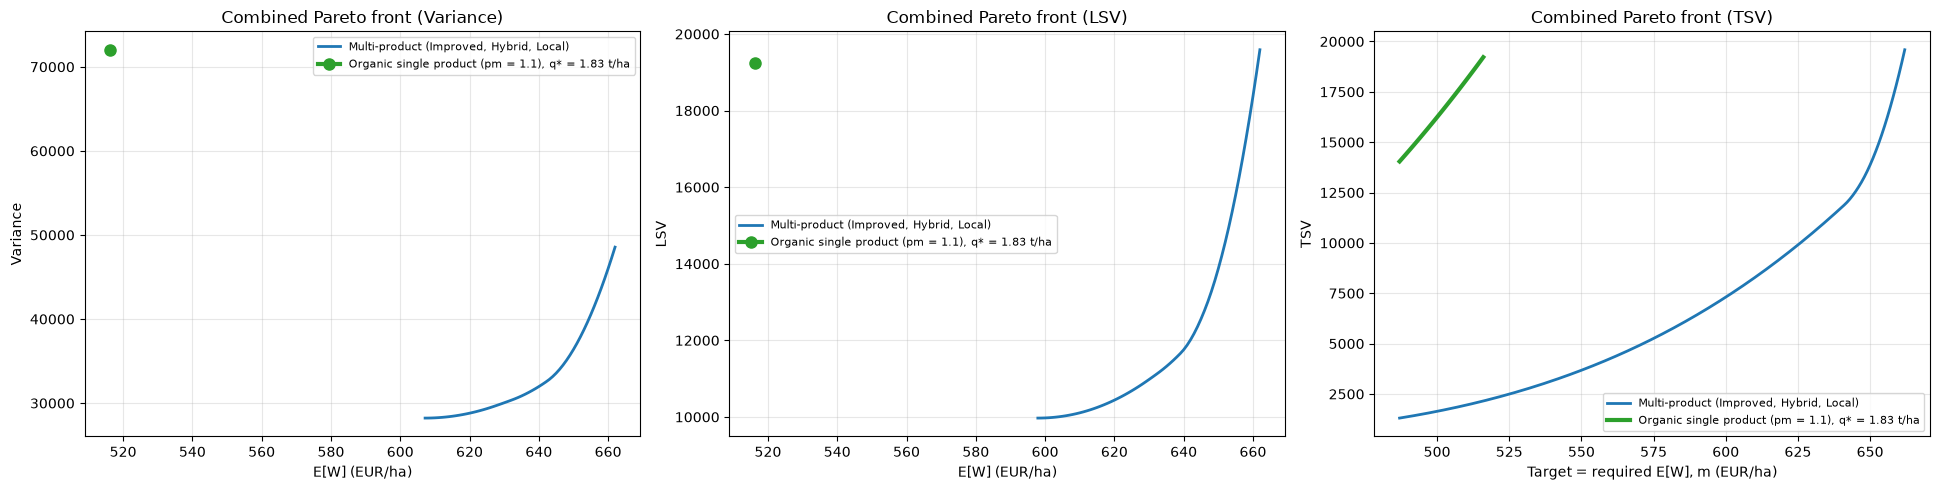

Variance: organic x = 516.2..516.2, risk = 72,030..72,030 | multi-product x = 607.2..662.0, risk = 28,220..48,552
LSV     : organic x = 516.2..516.2, risk = 19,254..19,254 | multi-product x = 597.9..662.0, risk = 9,970..19,589
TSV     : organic x = 487.0..516.0, risk = 14,044..19,218 | multi-product x = 487.0..662.0, risk = 1,304..19,589


In [15]:
#### Plot: combined Pareto front (base-case organic forward price) ####
fig, axes = plt.subplots(1, len(RISK_METRICS), figsize=(6.5 * len(RISK_METRICS), 5))
for ax, metric in zip(np.atleast_1d(axes), RISK_METRICS):
    x_m, y_m = multi_front(metric)
    ax.plot(x_m, y_m, color="tab:blue", linewidth=2, label="Multi-product (Improved, Hybrid, Local)")

    x_o, y_o, q_o = organic_front(pm_org_base, metric)
    ax.plot(x_o, y_o, color="tab:green", linewidth=3, marker="o" if len(x_o) < 3 else None, markersize=8,
            label=f"Organic single product (pm = {pm_org_base}), q* = {np.nanmin(q_o):.2f}" +
                  (f"..{np.nanmax(q_o):.2f}" if np.nanmax(q_o) - np.nanmin(q_o) > 1e-6 else "") + " t/ha")
    ax.set_xlabel(X_LABEL[metric])
    ax.set_ylabel(metric)
    ax.set_title(f"Combined Pareto front ({metric})")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

for metric in RISK_METRICS:
    x_o, y_o, _ = organic_front(pm_org_base, metric)
    x_m, y_m = multi_front(metric)
    print(f"{metric:8s}: organic x = {x_o.min():.1f}..{x_o.max():.1f}, risk = {y_o.min():,.0f}..{y_o.max():,.0f} | "
          f"multi-product x = {x_m.min():.1f}..{x_m.max():.1f}, risk = {y_m.min():,.0f}..{y_m.max():,.0f}")

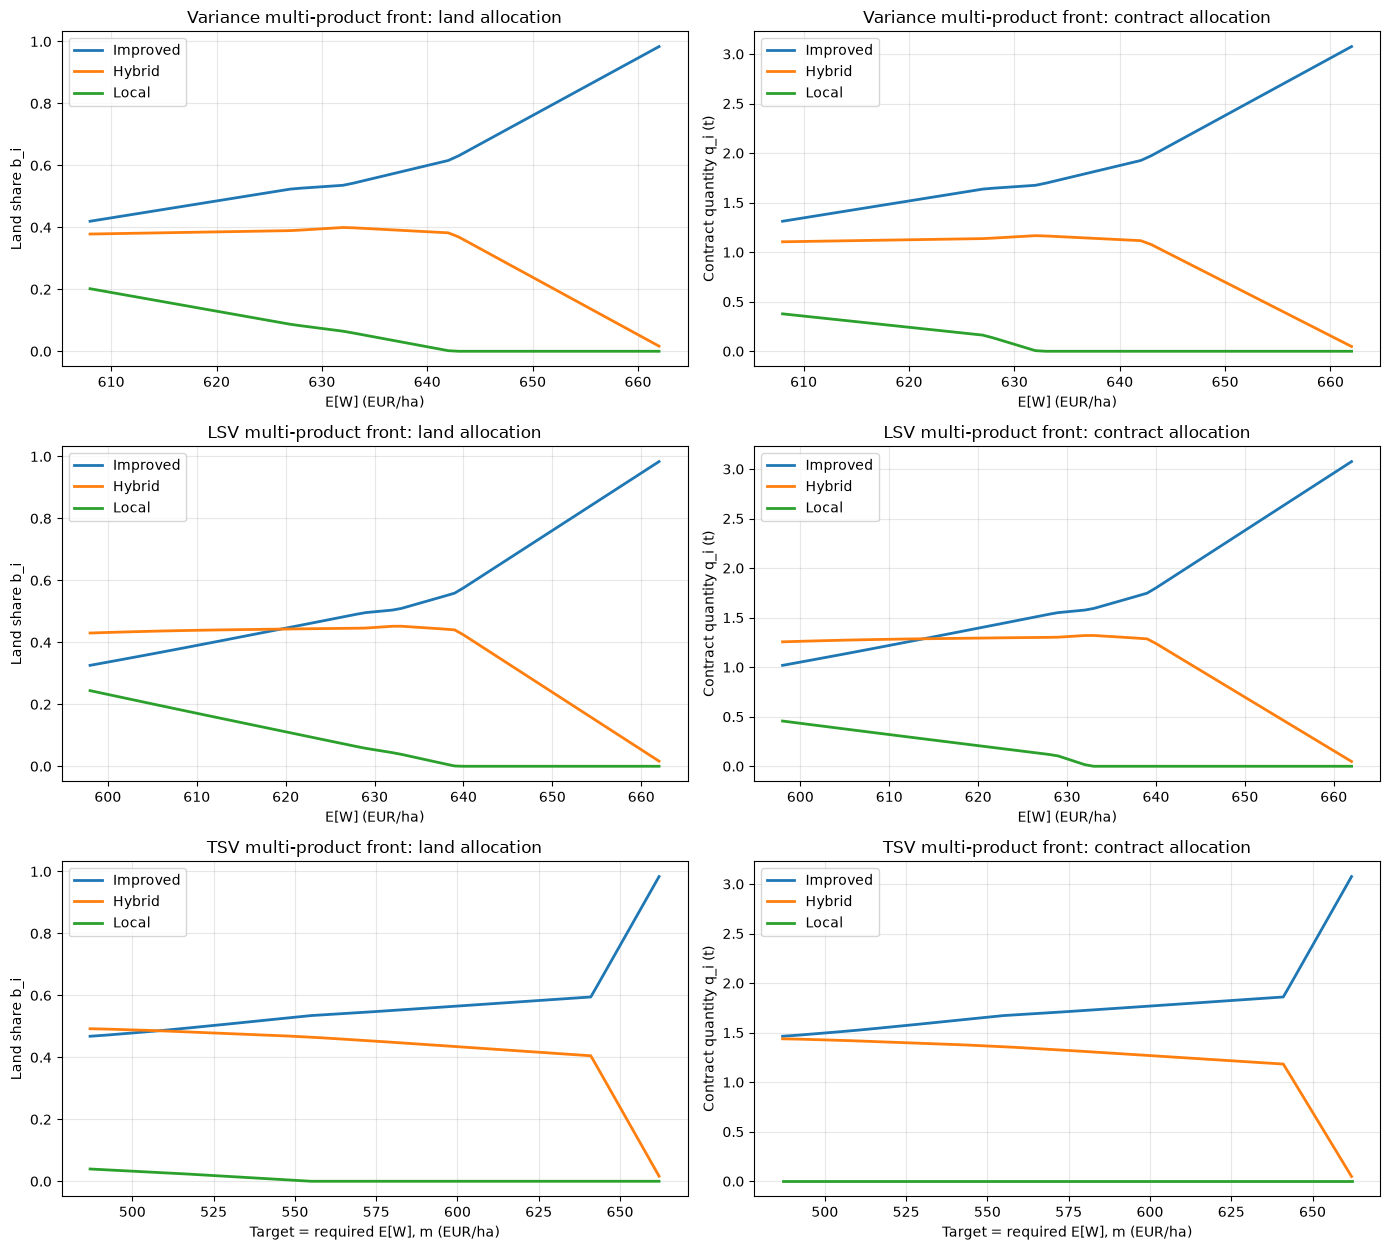

In [16]:
#### Multi-product allocation along the front (for reference) ####
fig, axes = plt.subplots(len(RISK_METRICS), 2, figsize=(14, 4.2 * len(RISK_METRICS)), squeeze=False)
for row, metric in enumerate(RISK_METRICS):
    res = multi[metric]
    if metric == "TSV":
        keep = np.isfinite(res["risk"]); x = m_grid[keep]
    else:
        keep = np.isfinite(res["risk"]) & (m_grid >= res["E_start"]); x = res["E"][keep]
    for i, crop in enumerate(crop_names_multi):
        axes[row, 0].plot(x, res["b"][keep, i], linewidth=2, label=crop)
        axes[row, 1].plot(x, res["q"][keep, i], linewidth=2, label=crop)
    axes[row, 0].set_ylabel("Land share b_i"); axes[row, 1].set_ylabel("Contract quantity q_i (t)")
    for ax, what in zip(axes[row], ["land allocation", "contract allocation"]):
        ax.set_xlabel(X_LABEL[metric]); ax.set_title(f"{metric} multi-product front: {what}")
        ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()
plt.show()

## Influence of the organic forward price

The organic forward price is varied as $f_{org} = pm \cdot \mathbb{E}[P_{org}]$ over `pm_org_range`, while the
conventional multi-product model is kept fixed. For every $pm$, and every required expectation $m$ between the
start and end of the combined front (1 EUR steps, as in `examine_forward_price_influence`), the organic option is
**preferred** if its minimal risk with $\mathbb{E}[W] \ge m$ is at most that of the multi-product model (or if only
the organic option can reach $m$).

The start of the combined front is the lowest minimum-risk expectation of the two models, the end the highest
attainable expectation. TSV has no minimum-risk point (it falls to 0 for low targets), so for TSV the same
$m$-range as for Variance is used, which keeps the shares comparable.

Summaries per $pm$:
- **Risk averse**: preference at the lowest $m$ of the combined front (minimum-risk end).
- **Risk neutral**: preference at the middle $m$ of the combined front.
- **Risk loving**: preference at the highest $m$ (maximum-expectation end).
- **Pareto front average**: share of the combined front where organic is preferred, plus the lower and upper half.
- Mean organic contract $q^*$ over the front (0 where conventional is preferred), used for the premium cost.

For Variance and LSV the organic risk does not depend on $f_{org}$: a higher forward price only moves the organic
front to the right, and for $pm > 1$ contracting the maximum $q = r_{org}$ is both the highest-expectation and the
lowest-risk choice, so the organic front collapses to a single point. Under TSV a higher $f_{org}$ also raises
every realised income, so it lowers the organic TSV for a given target.

In [17]:
#### Sweep the organic forward price ####
def comparison_range(pm, metric):
    base_metric = "Variance" if metric == "TSV" else metric
    E_o = organic_front_EV(pm, base_metric)[0]
    start = min(E_o.min(), multi[base_metric]["E_start"])
    end = max(E_o.max(), E_max_multi)
    return (m_grid >= np.floor(start)) & (m_grid <= end + 1e-9)   # as range(floor(start), ceil(end))

def compare_at_pm(pm, metric):
    sel = comparison_range(pm, metric)
    risk_org, q_org = organic_min_risk(pm, metric)
    risk_org, q_org = risk_org[sel], q_org[sel]
    risk_multi = multi[metric]["risk"][sel]
    engage = (np.isfinite(risk_org) & (risk_org <= risk_multi)).astype(float)
    q_engaged = np.where(engage == 1, q_org, 0.0)
    return m_grid[sel], engage, q_engaged

forward_results = {}
for metric in RISK_METRICS:
    out = {k: [] for k in ["risk_averse", "risk_neutral", "risk_loving", "average",
                           "lower_half", "upper_half", "q_avg", "q_low", "q_high"]}
    pref_rows = []
    for pm in pm_org_range:
        m_sel, engage, q_eng = compare_at_pm(pm, metric)
        mid = len(engage) // 2
        out["risk_averse"].append(engage[0])
        out["risk_neutral"].append(engage[mid])
        out["risk_loving"].append(engage[-1])
        out["average"].append(engage.mean())
        out["lower_half"].append(engage[:mid].mean() if mid > 0 else 0.0)
        out["upper_half"].append(engage[mid:].mean() if mid > 0 else 0.0)
        out["q_avg"].append(q_eng.mean())
        out["q_low"].append(q_eng[:mid].mean() if mid > 0 else 0.0)
        out["q_high"].append(q_eng[mid:].mean() if mid > 0 else 0.0)
        row = np.full(len(m_grid), np.nan)          # preference on the full m-grid (heatmap)
        row[np.isin(m_grid, m_sel)] = engage
        pref_rows.append(row)
    forward_results[metric] = {k: np.array(v) for k, v in out.items()}
    forward_results[metric]["pref_matrix"] = np.array(pref_rows)

# Break-even forward price: organic (q = r_org) reaches beyond the multi-product maximum E[W]
pm_break_even = 1 + (E_max_multi - PQbar_org) / (r_org * Pbar_org)
print(f"Organic E[W] at q = r_org exceeds the multi-product maximum ({E_max_multi:.1f} EUR/ha) for pm > {pm_break_even:.3f}")
for metric in RISK_METRICS:
    fr = forward_results[metric]
    first = pm_org_range[np.argmax(fr["average"] > 0)] if np.any(fr["average"] > 0) else None
    print(f"{metric:8s}: organic first preferred somewhere on the front at pm = {first}; "
          f"share of front at pm = {pm_org_range[-1]:.2f}: {fr['average'][-1]:.1%}")

Organic E[W] at q = r_org exceeds the multi-product maximum (662.9 EUR/ha) for pm > 1.635
Variance: organic first preferred somewhere on the front at pm = 1.64; share of front at pm = 2.00: 64.1%
LSV     : organic first preferred somewhere on the front at pm = 1.64; share of front at pm = 2.00: 60.8%
TSV     : organic first preferred somewhere on the front at pm = 1.64; share of front at pm = 2.00: 100.0%


Variance: organic front at pm = 1.00 has E[W] = 488.8..488.8, risk = 110,267..110,267
Variance: organic front at pm = 1.20 has E[W] = 543.6..543.6, risk = 72,030..72,030
Variance: organic front at pm = 1.40 has E[W] = 598.4..598.4, risk = 72,030..72,030
Variance: organic front at pm = 1.60 has E[W] = 653.2..653.2, risk = 72,030..72,030
Variance: organic front at pm = 1.80 has E[W] = 708.1..708.1, risk = 72,030..72,030
Variance: organic front at pm = 2.00 has E[W] = 762.9..762.9, risk = 72,030..72,030
LSV     : organic front at pm = 1.00 has E[W] = 488.8..488.8, risk = 27,770..27,770
LSV     : organic front at pm = 1.20 has E[W] = 543.6..543.6, risk = 19,254..19,254
LSV     : organic front at pm = 1.40 has E[W] = 598.4..598.4, risk = 19,254..19,254
LSV     : organic front at pm = 1.60 has E[W] = 653.2..653.2, risk = 19,254..19,254
LSV     : organic front at pm = 1.80 has E[W] = 708.1..708.1, risk = 19,254..19,254
LSV     : organic front at pm = 2.00 has E[W] = 762.9..762.9, risk = 19,25

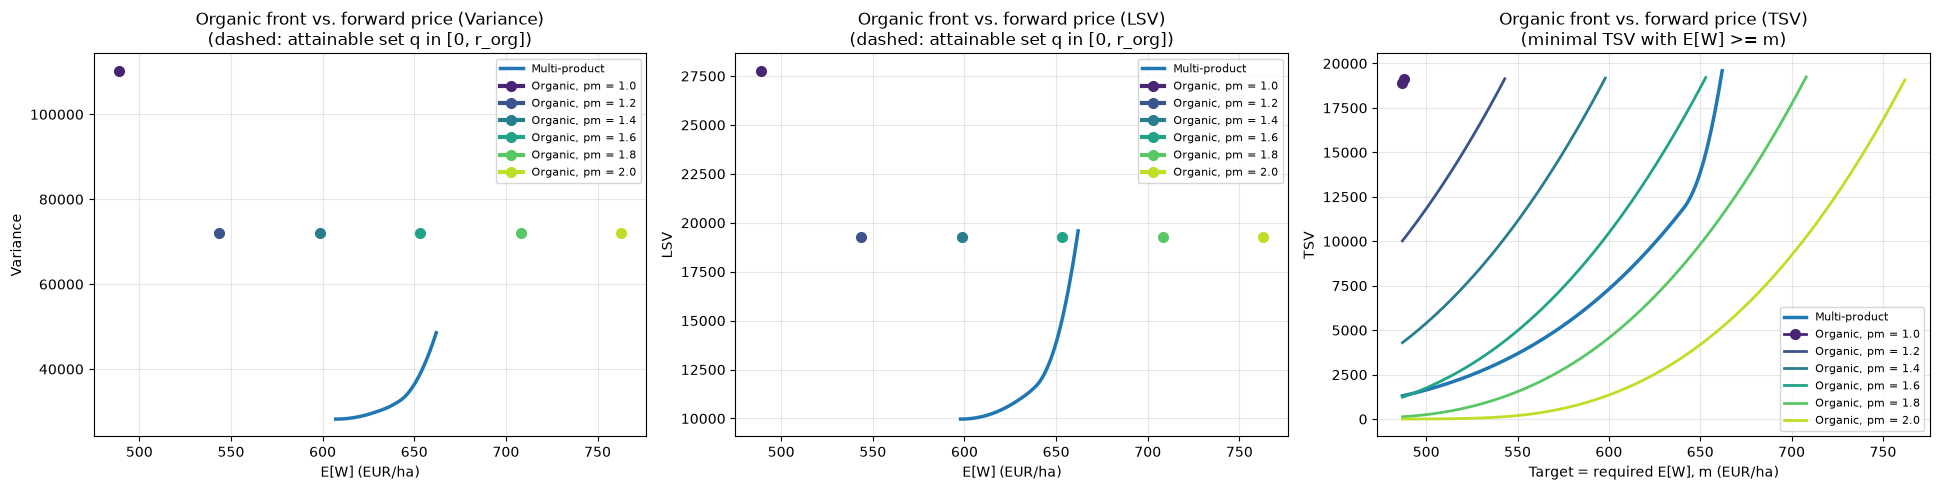

In [ ]:
#### Plot: organic fronts for several forward prices against the multi-product front ####
pm_show = [1.0, 1.2, 1.4, 1.6, 1.8, 2.0]
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(pm_show)))

fig, axes = plt.subplots(1, len(RISK_METRICS), figsize=(6.5 * len(RISK_METRICS), 5))
for ax, metric in zip(np.atleast_1d(axes), RISK_METRICS):
    x_m, y_m = multi_front(metric)
    ax.plot(x_m, y_m, color="tab:blue", linewidth=2.5, label="Multi-product")
    for pm, col in zip(pm_show, colors):
        x_o, y_o, q_o = organic_front(pm, metric)
        if len(x_o) > 1:
            min_sep = 0.01 * x_o.max() if metric != "TSV" else 0.0
            n = len(x_o) - 1
            keep = [n]
            for i in range(n - 1, -1, -1):
                if x_o[keep[-1]] - x_o[i] >= min_sep:
                    keep.append(i)
            idx = np.asarray(keep)
            x_o, y_o, q_o = x_o[idx], y_o[idx], q_o[idx]
        print(f"{metric:8s}: organic front at pm = {pm:.2f} has E[W] = {x_o.min():.1f}..{x_o.max():.1f}, "
              f"risk = {y_o.min():,.0f}..{y_o.max():,.0f}")
        ax.plot(x_o, y_o, color=col, linewidth=3 if metric != "TSV" else 2, marker="o",
                markersize=7 if len(x_o) < 3 else 0, label=f"Organic, pm = {pm:.1f}")
    ax.set_xlabel(X_LABEL[metric])
    ax.set_ylabel(metric)
    sub = "(dashed: attainable set q in [0, r_org])" if metric != "TSV" else "(minimal TSV with E[W] >= m)"
    ax.set_title(f"Organic front vs. forward price ({metric})\n{sub}")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

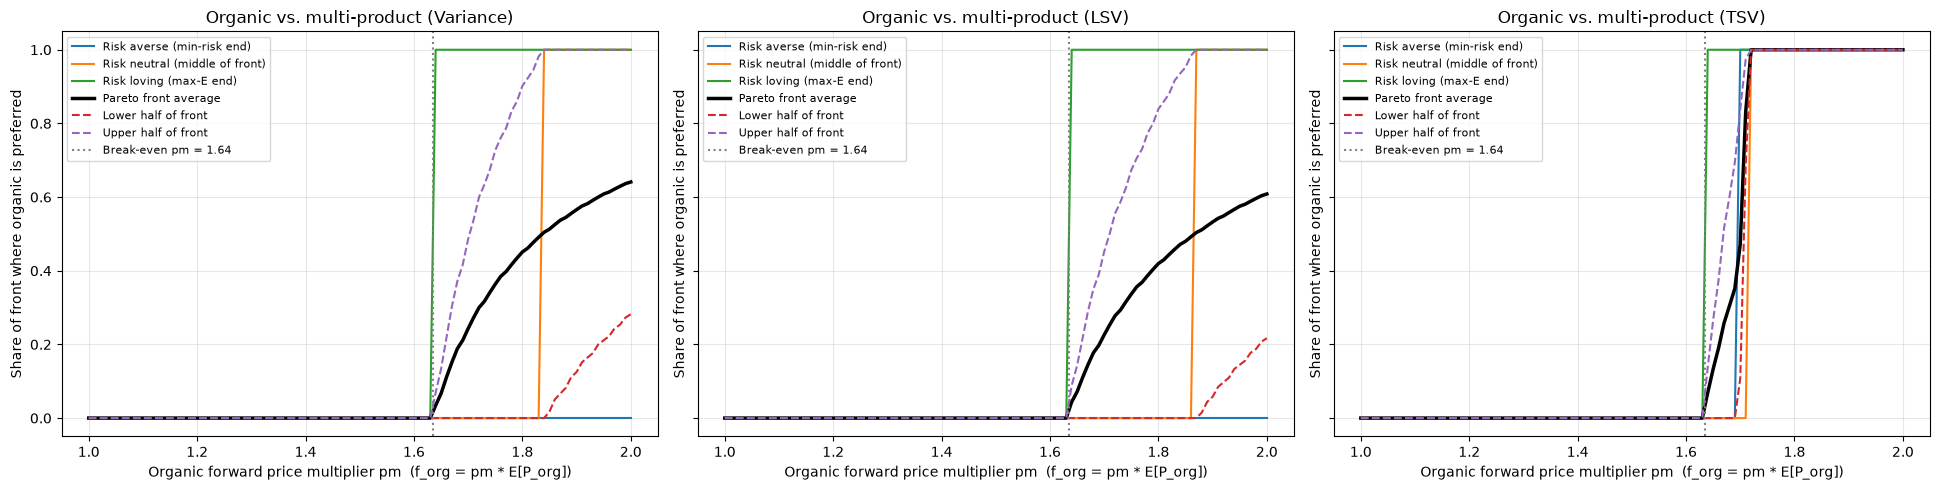

In [19]:
#### Plot: organic farming preference against the forward price premium ####
fig, axes = plt.subplots(1, len(RISK_METRICS), figsize=(6.5 * len(RISK_METRICS), 5), sharey=True)
for ax, metric in zip(np.atleast_1d(axes), RISK_METRICS):
    fr = forward_results[metric]
    ax.plot(pm_org_range, fr["risk_averse"],  label="Risk averse (min-risk end)")
    ax.plot(pm_org_range, fr["risk_neutral"], label="Risk neutral (middle of front)")
    ax.plot(pm_org_range, fr["risk_loving"],  label="Risk loving (max-E end)")
    ax.plot(pm_org_range, fr["average"], linewidth=2.5, color="black", label="Pareto front average")
    ax.plot(pm_org_range, fr["lower_half"], linestyle="--", label="Lower half of front")
    ax.plot(pm_org_range, fr["upper_half"], linestyle="--", label="Upper half of front")
    ax.axvline(pm_break_even, color="grey", linestyle=":", label=f"Break-even pm = {pm_break_even:.2f}")
    ax.set_xlabel("Organic forward price multiplier pm  (f_org = pm * E[P_org])")
    ax.set_ylabel("Share of front where organic is preferred")
    ax.set_title(f"Organic vs. multi-product ({metric})")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

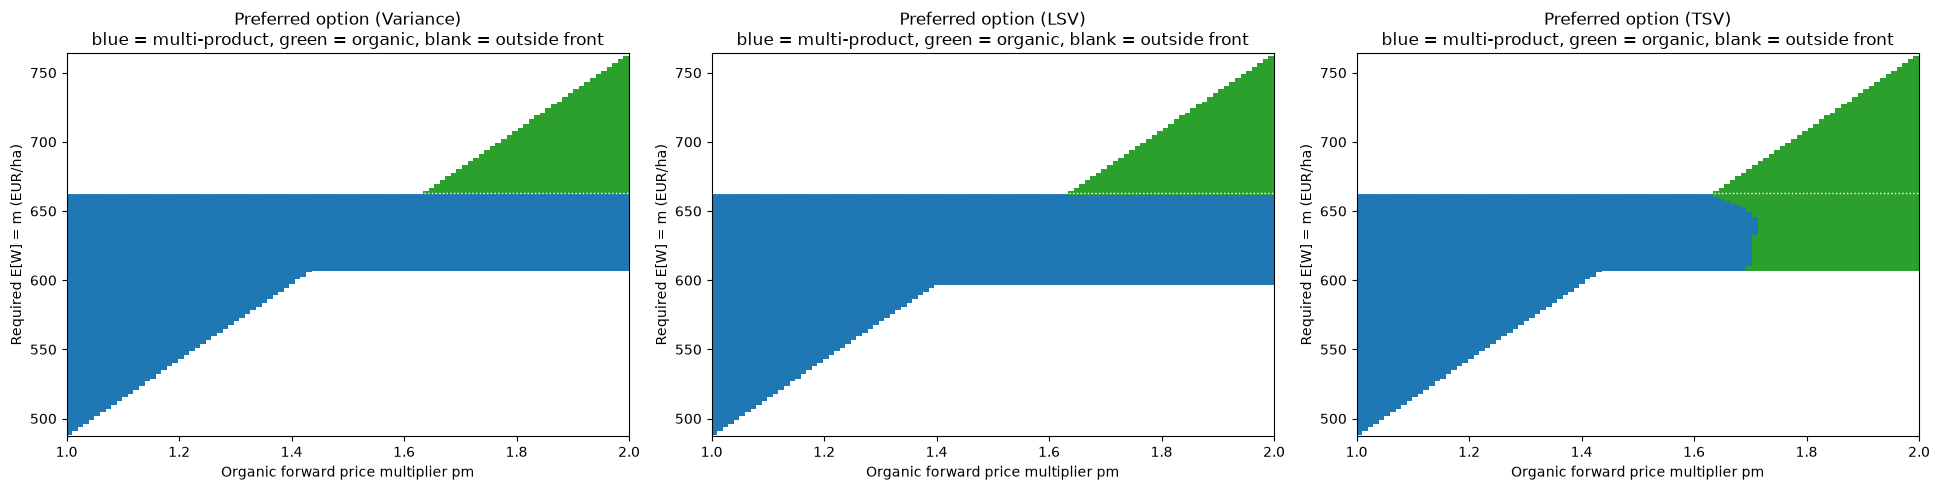

In [20]:
#### Heatmap: preferred option per (forward price, required E[W]) ####
from matplotlib.colors import ListedColormap
cmap = ListedColormap(["tab:blue", "tab:green"])
fig, axes = plt.subplots(1, len(RISK_METRICS), figsize=(6.5 * len(RISK_METRICS), 5))
for ax, metric in zip(np.atleast_1d(axes), RISK_METRICS):
    pref = forward_results[metric]["pref_matrix"]           # (n_pm, n_m)
    ax.imshow(np.ma.masked_invalid(pref.T), origin="lower", aspect="auto", cmap=cmap, vmin=0, vmax=1,
              extent=[pm_org_range[0], pm_org_range[-1], m_grid[0], m_grid[-1]], interpolation="nearest")
    ax.axhline(E_max_multi, color="white", linestyle=":", linewidth=1)
    ax.set_xlabel("Organic forward price multiplier pm")
    ax.set_ylabel("Required E[W] = m (EUR/ha)")
    ax.set_title(f"Preferred option ({metric})\nblue = multi-product, green = organic, blank = outside front")
plt.tight_layout()
plt.show()

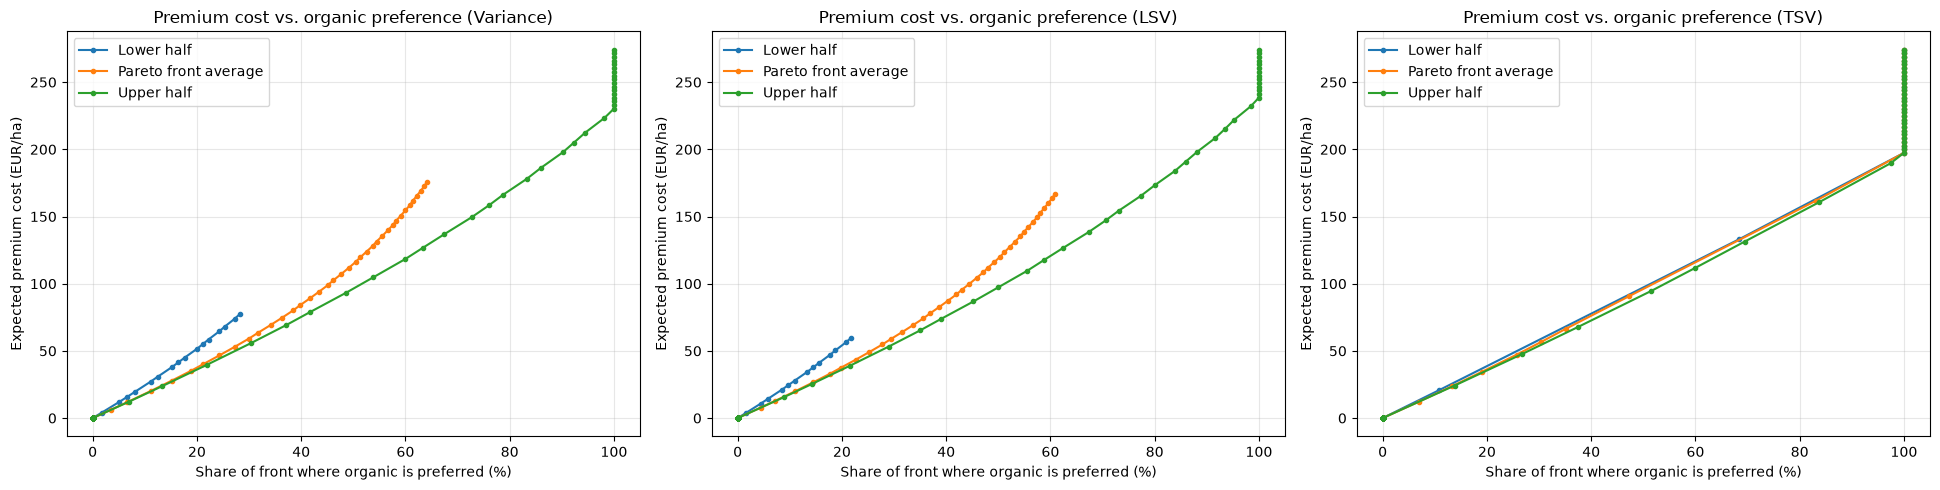

,pm,Variance: front avg,LSV: front avg,TSV: front avg,Variance: mean q*,LSV: mean q*,TSV: mean q*,premium cost at q=r_org (EUR/ha)
0,1.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000
10,1.1,0.000,0.000,0.000,0.000,0.000,0.000,27.413
20,1.2,0.000,0.000,0.000,0.000,0.000,0.000,54.825
30,1.3,0.000,0.000,0.000,0.000,0.000,0.000,82.238
40,1.4,0.000,0.000,0.000,0.000,0.000,0.000,109.650
50,1.5,0.000,0.000,0.000,0.000,0.000,0.000,137.063
60,1.6,0.000,0.000,0.000,0.000,0.000,0.000,164.475
70,1.7,0.243,0.226,0.473,0.445,0.414,0.866,191.888
80,1.8,0.451,0.420,1.000,0.826,0.768,1.831,219.300
90,1.9,0.566,0.532,1.000,1.036,0.975,1.831,246.713


In [21]:
#### Expected premium cost per hectare for the buyer ####
# cost = (mean organic q* over the front, 0 where conventional is preferred) * (pm - 1) * E[P_org]
fig, axes = plt.subplots(1, len(RISK_METRICS), figsize=(6.5 * len(RISK_METRICS), 5))
for ax, metric in zip(np.atleast_1d(axes), RISK_METRICS):
    fr = forward_results[metric]
    for share, q_avg, label in [(fr["lower_half"], fr["q_low"], "Lower half"),
                                (fr["average"],    fr["q_avg"], "Pareto front average"),
                                (fr["upper_half"], fr["q_high"], "Upper half")]:
        cost = q_avg * (pm_org_range - 1) * Pbar_org
        ax.plot(share * 100, cost, marker=".", label=label)
    ax.set_xlabel("Share of front where organic is preferred (%)")
    ax.set_ylabel("Expected premium cost (EUR/ha)")
    ax.set_title(f"Premium cost vs. organic preference ({metric})")
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()

summary = pd.DataFrame({
    "pm": pm_org_range,
    **{f"{metric}: front avg": forward_results[metric]["average"] for metric in RISK_METRICS},
    **{f"{metric}: mean q*": forward_results[metric]["q_avg"] for metric in RISK_METRICS},
})
summary["premium cost at q=r_org (EUR/ha)"] = r_org * (pm_org_range - 1) * Pbar_org
summary.iloc[::10].round(3)